# Workshop 2 — Machine Learning
### Regresión — Flight Price Prediction

**Equipo:** Cristian Cabezas, Mateo Lopera y Juanes Villada

En este notebook resolvemos el problema de **regresión** del Workshop 2: predecir el precio de un tiquete aéreo doméstico en India a partir de las características del vuelo. Seguimos el ciclo completo visto en clase: EDA, limpieza, preprocesamiento con pipelines, entrenamiento y comparación de varios algoritmos, detección de overfitting/underfitting, evaluación final en test y validación cruzada. El notebook de clasificación (enfermedad tiroidea) está en un archivo aparte, tal como lo pide el enunciado.

Cada decisión de limpieza, codificación o escalamiento va acompañada de una celda de texto que explica **por qué** la tomamos, no solo el código que la ejecuta.

## Fase 1 — EDA, limpieza y preprocesamiento

### 1. Problema de negocio y variable objetivo

El dataset **Flight Price Prediction** (Kaggle, `shubhambathwal/flight-price-prediction`) reúne información recolectada de un sitio de reservas de vuelos, con tiquetes domésticos entre seis ciudades de India (Delhi, Mumbai, Bangalore, Kolkata, Hyderabad y Chennai) operados por seis aerolíneas indias (SpiceJet, AirAsia, Vistara, GO_FIRST, Indigo y Air India).

**Problema de negocio:** una aerolínea o una agencia de viajes quiere anticipar qué precio tendrá un tiquete según sus características (aerolínea, ruta, horario, número de escalas, clase y con cuánta anticipación se compra), para apoyar decisiones de pricing dinámico, presupuesto de viaje corporativo o alertas de compra al usuario final.

**Variable objetivo (target):** `price`, el precio del tiquete. Es una variable numérica continua, por lo que este es un problema de **regresión supervisada**.

El archivo trae tres CSV (`Clean_Dataset.csv`, `economy.csv`, `business.csv`); usamos **`Clean_Dataset.csv`** porque ya integra ambas clases de cabina en un solo archivo con las columnas que necesitamos, y es el que la documentación del dataset señala como el conjunto "limpio" listo para modelar.

In [1]:
# Bloque 1: importar librerías y cargar el dataset
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42
sns.set_style("whitegrid")

DATASET_HANDLE = "shubhambathwal/flight-price-prediction"
ARCHIVO = "Clean_Dataset.csv"

ruta_local = Path(ARCHIVO)
if ruta_local.exists():
    ruta_csv = ruta_local
    print("Usando el archivo local:", ruta_csv)
else:
    try:
        import kagglehub
        carpeta = Path(kagglehub.dataset_download(DATASET_HANDLE))
        ruta_csv = carpeta / ARCHIVO
        print("Archivo descargado desde Kaggle:", ruta_csv)
    except Exception as error_descarga:
        if "google.colab" in sys.modules:
            from google.colab import files
            print("No fue posible descargar el archivo. Súbalo manualmente.")
            archivos_subidos = files.upload()
            if ARCHIVO not in archivos_subidos:
                raise FileNotFoundError(
                    f"No se encontró {ARCHIVO} entre los archivos subidos."
                ) from error_descarga
            ruta_csv = Path(ARCHIVO)
        else:
            raise RuntimeError(
                "No fue posible obtener Clean_Dataset.csv. Instale kagglehub o "
                "ubique el archivo en la misma carpeta del notebook."
            ) from error_descarga

df_original = pd.read_csv(ruta_csv)
print("Tamaño original:", df_original.shape)
df_original.head()

C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Archivo descargado desde Kaggle: C:\Users\USER\.cache\kagglehub\datasets\shubhambathwal\flight-price-prediction\versions\2\Clean_Dataset.csv


Tamaño original: (300153, 12)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [2]:
# Primeras y últimas filas, shape e info
print("Primeras cinco filas:")
display(df_original.head())

print("\nÚltimas cinco filas:")
display(df_original.tail())

print("\nFilas y columnas:", df_original.shape)
df_original.info()

Primeras cinco filas:


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955



Últimas cinco filas:


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585



Filas y columnas: (300153, 12)
<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 42.9 MB


**Diccionario de datos**

| Columna | Tipo esperado | Significado |
|---|---|---|
| `Unnamed: 0` | numérico entero | Índice heredado del archivo original; no aporta información, se elimina |
| `airline` | categórica nominal | Aerolínea que opera el vuelo (6 categorías) |
| `flight` | texto / identificador | Código del vuelo; funciona como un identificador, no como una variable predictiva |
| `source_city` | categórica nominal | Ciudad de origen (6 categorías) |
| `departure_time` | categórica nominal | Franja horaria de salida (6 categorías) |
| `stops` | categórica ordinal | Número de escalas: `zero`, `one`, `two_or_more` |
| `arrival_time` | categórica nominal | Franja horaria de llegada (6 categorías) |
| `destination_city` | categórica nominal | Ciudad de destino (6 categorías) |
| `class` | categórica ordinal (binaria) | Clase de cabina: `Economy` o `Business` |
| `duration` | numérico decimal | Duración total del vuelo, en horas |
| `days_left` | numérico entero | Días entre la fecha de compra y la fecha del vuelo |
| `price` | numérico entero | **Variable objetivo.** Precio del tiquete |

`Unnamed: 0` es un índice duplicado que el `to_csv()` original dejó guardado; lo eliminamos porque no representa ninguna característica del vuelo. `flight` tampoco la usamos como predictor: es un identificador con **1.561 valores distintos**, no tiene una relación generalizable con el precio (un mismo código de vuelo puede repetirse en fechas distintas con precios distintos) y convertirla en variable categórica agregaría cientos de columnas sin aportar señal real — solo la conservamos para la revisión de duplicados.

In [3]:
# Retiramos el índice heredado; 'flight' se conserva por ahora solo para revisar duplicados
df = df_original.drop(columns=["Unnamed: 0"]).copy()
print("Columnas de trabajo:", df.columns.tolist())
print("Tamaño:", df.shape)

Columnas de trabajo: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']
Tamaño: (300153, 11)


### 2-3. Estadísticos descriptivos

Aplicamos `.describe()` a las tres columnas numéricas: `duration`, `days_left` y `price`.

In [4]:
df[["duration", "days_left", "price"]].describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


Interpretamos tres estadísticos en el contexto del problema:

- **`price`:** la media es **20.889,66** y la mediana **7.425**. La media casi triplica la mediana, lo que indica una distribución muy sesgada hacia la derecha: hay un grupo de tiquetes mucho más caros (probablemente los de clase Business) que empujan el promedio hacia arriba, mientras que la mayoría de los tiquetes son más económicos.
- **`duration`:** el promedio es **12,22 horas** con una desviación estándar de **7,19**. El rango va de 0,83 a 49,83 horas, un abanico amplio que sugiere que el dataset mezcla vuelos directos cortos con itinerarios de varias escalas mucho más largos.
- **`days_left`:** varía entre 1 y 49 días con una media de **26,00** y una mediana idéntica de **26**, casi simétrica. Esto tiene sentido porque el sitio de reservas capturó los precios en una ventana fija de anticipación (1 a 49 días antes del vuelo), no es una variable con sesgo natural como el precio.

No calculamos `.describe()` sobre `flight` porque es un identificador de texto, y las categorías (`airline`, `stops`, `class`, etc.) las resumimos por separado con conteos de frecuencia más adelante.

### 4. Valores nulos

Revisamos nulos por columna y su porcentaje.

In [5]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje_nulos.round(2)})
resumen_nulos

,Nulos,Porcentaje (%)
airline,0,0.0
flight,0,0.0
source_city,0,0.0
departure_time,0,0.0
stops,0,0.0
arrival_time,0,0.0
destination_city,0,0.0
class,0,0.0
duration,0,0.0
days_left,0,0.0


**No hay valores nulos en ninguna columna (0,00 % en todas).** Esto es coherente con que `Clean_Dataset.csv` ya es la versión curada del dataset original (la fuente aclara que este archivo fue depurado antes de publicarse).

Aun así, incluimos un `SimpleImputer` dentro del pipeline de preprocesamiento (Fase 2). No es necesario para *este* conjunto de datos, pero es una buena práctica: si el modelo se usara en producción con datos nuevos que sí llegaran con campos vacíos (por ejemplo, una `duration` que no se pudo calcular), el pipeline seguiría funcionando sin romperse en vez de fallar por un valor faltante inesperado.

### 5. Duplicados

Buscamos filas completamente duplicadas, y por separado revisamos qué pasa si ignoramos `flight` (porque dos vuelos distintos podrían compartir exactamente los mismos atributos observables sin ser el mismo registro).

In [6]:
duplicados_completos = df.duplicated().sum()
duplicados_sin_flight = df.drop(columns=["flight"]).duplicated().sum()

print("Filas completamente duplicadas (incluyendo 'flight'):", int(duplicados_completos))
print("Filas con los mismos atributos pero sin considerar 'flight':", int(duplicados_sin_flight))
print("Códigos de vuelo distintos ('flight'):", int(df["flight"].nunique()), "de", len(df), "filas")

Filas completamente duplicadas (incluyendo 'flight'): 0
Filas con los mismos atributos pero sin considerar 'flight': 2213
Códigos de vuelo distintos ('flight'): 1561 de 300153 filas


**No encontramos ninguna fila completamente duplicada.** Al ignorar `flight` sí aparecen **2.213** combinaciones repetidas de aerolínea/ruta/horario/escalas/clase/duración/precio, pero esto no es un duplicado de captura: son vuelos con el mismo código (`flight`) que se ofrecen varias veces en el sitio de reservas para distintas fechas de consulta, o vuelos de aerolíneas distintas que coinciden por casualidad en esas características. Como de todas formas no vamos a usar `flight` como variable predictiva, no eliminamos esas filas: harían falta datos que no tenemos (por ejemplo, la fecha exacta de la consulta) para decidir si de verdad son observaciones repetidas o vuelos distintos.

Con esto confirmado, retiramos `flight` del conjunto de trabajo — ya cumplió su función para esta revisión.

In [7]:
df = df.drop(columns=["flight"])
print("Columnas finales:", df.columns.tolist())

Columnas finales: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


### 6. Inconsistencias de formato en columnas categóricas

Revisamos los valores únicos de cada columna categórica para detectar mayúsculas/minúsculas mezcladas, espacios sobrantes o etiquetas equivalentes escritas de forma distinta.

In [8]:
columnas_categoricas = ["airline", "source_city", "departure_time", "stops",
                        "arrival_time", "destination_city", "class"]

for columna in columnas_categoricas:
    valores = df[columna].unique()
    con_espacios = df[columna].astype(str).str.strip().ne(df[columna].astype(str)).sum()
    print(f"{columna} ({len(valores)} categorías, {con_espacios} con espacios externos): {list(valores)}")

airline (6 categorías, 0 con espacios externos): ['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
source_city (6 categorías, 0 con espacios externos): ['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
departure_time (6 categorías, 0 con espacios externos): ['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
stops (3 categorías, 0 con espacios externos): ['zero', 'one', 'two_or_more']
arrival_time (6 categorías, 0 con espacios externos): ['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']
destination_city (6 categorías, 0 con espacios externos): ['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
class (2 categorías, 0 con espacios externos): ['Economy', 'Business']


Las siete columnas categóricas ya llegan con etiquetas consistentes: nombres bien capitalizados (`SpiceJet`, `Delhi`, `Evening`), sin espacios externos y sin variantes equivalentes escritas de dos formas distintas (por ejemplo, no aparece `"delhi"` y `"Delhi"` como si fueran categorías separadas). `stops` usa `zero` / `one` / `two_or_more` de forma consistente en todo el archivo. No fue necesario aplicar ninguna corrección de formato — lo dejamos documentado porque el enunciado pide revisarlo explícitamente, no porque hubiera algo que arreglar.

### 7. Outliers (criterio IQR)

Aplicamos el criterio de rango intercuartílico (IQR) sobre `duration` y `price`, las dos columnas numéricas más relevantes para el negocio (no aplicamos el criterio a `days_left` porque es una variable acotada por diseño entre 1 y 49, no una medida donde tenga sentido buscar "valores atípicos").

In [9]:
def reporte_iqr(serie, nombre):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = (serie < lo) | (serie > hi)
    print(f"--- {nombre} ---")
    print(f"Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
    print(f"Límites: [{lo:.2f}, {hi:.2f}]")
    print(f"Atípicos: {int(atipicos.sum())} ({atipicos.mean()*100:.2f} %)\n")
    return atipicos

atipicos_duration = reporte_iqr(df["duration"], "duration (horas)")
atipicos_price = reporte_iqr(df["price"], "price")

--- duration (horas) ---
Q1=6.83  Q3=16.17  IQR=9.34
Límites: [-7.18, 30.18]
Atípicos: 2110 (0.70 %)

--- price ---
Q1=4783.00  Q3=42521.00  IQR=37738.00
Límites: [-51824.00, 99128.00]
Atípicos: 123 (0.04 %)



In [10]:
print("Vuelos con duración atípicamente larga (top 5):")
display(df.loc[atipicos_duration].sort_values("duration", ascending=False)
        [["airline", "source_city", "destination_city", "stops", "duration", "price"]].head())

print("\nTiquetes con precio atípicamente alto (top 5):")
display(df.loc[atipicos_price].sort_values("price", ascending=False)
        [["airline", "source_city", "destination_city", "class", "days_left", "price"]].head())

Vuelos con duración atípicamente larga (top 5):


,airline,source_city,destination_city,stops,duration,price
193889,Air_India,Chennai,Bangalore,two_or_more,49.83,23891
194359,Air_India,Chennai,Bangalore,one,49.83,17538
119508,Air_India,Bangalore,Chennai,one,47.75,7461
261152,Air_India,Bangalore,Chennai,one,47.75,55122
193926,Vistara,Chennai,Bangalore,one,47.08,17223



Tiquetes con precio atípicamente alto (top 5):


,airline,source_city,destination_city,class,days_left,price
261377,Vistara,Kolkata,Delhi,Business,3,123071
216096,Vistara,Delhi,Kolkata,Business,5,117307
215859,Vistara,Delhi,Kolkata,Business,1,116562
277345,Vistara,Hyderabad,Mumbai,Business,3,115211
270999,Vistara,Kolkata,Hyderabad,Business,17,114705


**`duration`:** el límite superior del IQR es **30,18 horas**. Encontramos **2.110 vuelos (0,70 %)** por encima de ese límite, casi todos con dos o más escalas entre ciudades indias. Tiene sentido de negocio: un vuelo doméstico con varias escalas puede fácilmente superar las 30 horas de viaje total, no es un error de captura. **No los eliminamos**: son observaciones legítimas y, además, informativas — el modelo necesita ver estos casos para aprender que más escalas y más duración están asociadas a patrones de precio distintos.

**`price`:** el límite superior es **99.128**. Solo **123 tiquetes (0,04 %)** lo superan, concentrados en vuelos de clase Business de última hora (`days_left` bajo) operados por Vistara y Air India. Tampoco los eliminamos: un tiquete Business comprado con pocos días de anticipación siendo caro es exactamente el tipo de patrón que un modelo de precios necesita aprender, no un error.

En ambos casos documentamos los atípicos, pero no los tratamos ni los removemos: tienen una explicación de negocio razonable y removerlos le restaría al modelo justo los casos "extremos" que más aportan para predecir bien esos rangos de precio.

### 8. Gráficas de EDA

Para cada gráfica incluimos el código, la imagen y un párrafo de interpretación con una recomendación de negocio.

**Gráfica 1 — Barras: cantidad de vuelos por aerolínea**

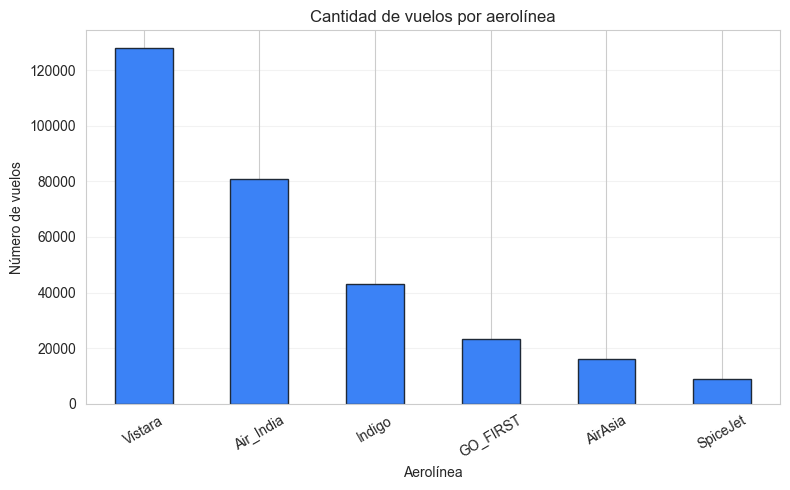

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [11]:
conteo_airline = df["airline"].value_counts()

plt.figure(figsize=(8, 5))
conteo_airline.plot(kind="bar", color="#3B82F6", edgecolor="#1F2937")
plt.title("Cantidad de vuelos por aerolínea")
plt.xlabel("Aerolínea")
plt.ylabel("Número de vuelos")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

conteo_airline

Vistara e Indigo son las aerolíneas con más vuelos registrados, y Vistara además es la más cara en promedio (lo vemos en la gráfica de barras de precio más adelante). SpiceJet, AirAsia y GO_FIRST son aerolíneas de bajo costo con muchos menos registros pero tiquetes más económicos.

**Recomendación:** para un proyecto de pricing conviene modelar `airline` como categórica y no ignorarla — la aerolínea concentra buena parte de la variación de precio, incluso antes de mirar clase o escalas.

**Gráfica 2 — Circular: participación de vuelos por número de escalas**

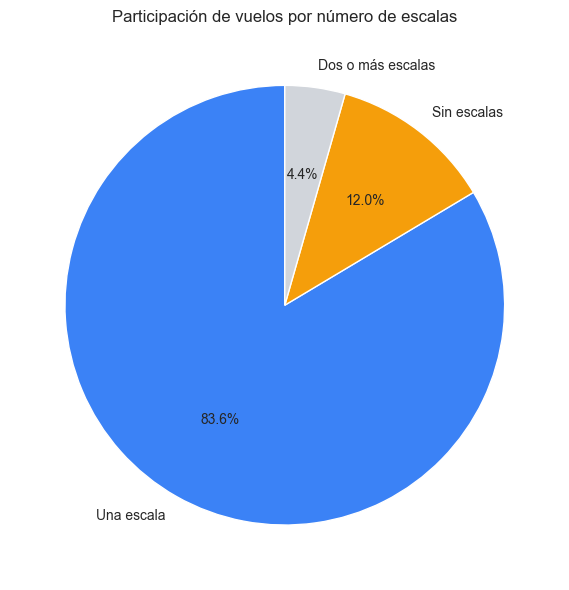

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [12]:
conteo_stops = df["stops"].value_counts()
etiquetas_stops = {"zero": "Sin escalas", "one": "Una escala", "two_or_more": "Dos o más escalas"}

plt.figure(figsize=(6, 6))
plt.pie(
    conteo_stops,
    labels=[etiquetas_stops[i] for i in conteo_stops.index],
    autopct="%1.1f%%",
    colors=["#3B82F6", "#F59E0B", "#D1D5DB"],
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
plt.title("Participación de vuelos por número de escalas")
plt.tight_layout()
plt.show()

conteo_stops

La gran mayoría de los vuelos, **83,6 %**, tiene al menos una escala; solo el resto son vuelos directos. Los vuelos de dos o más escalas son una minoría pequeña.

**Recomendación:** dado que `stops` domina la composición del dataset con "una escala", conviene comunicar con cuidado cualquier estimación de precio para vuelos directos, porque hay relativamente menos observaciones para entrenar bien ese segmento.

**Gráfica 3 — Histograma: distribución del precio**

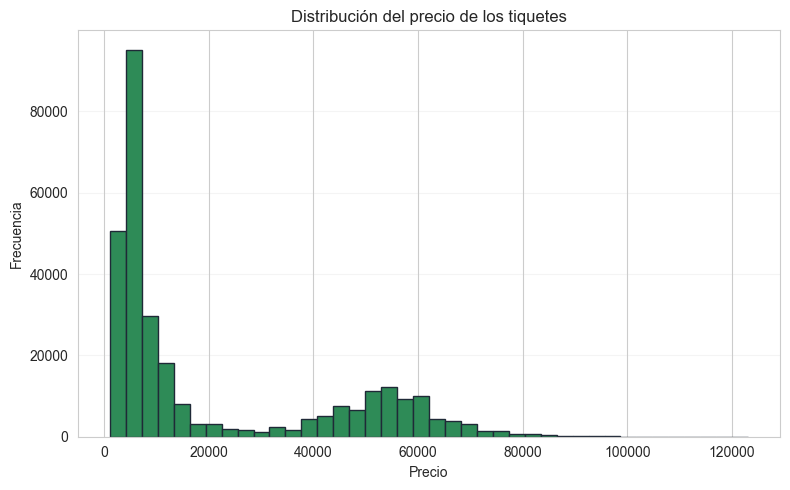

Coeficiente de asimetría: 1.061


In [13]:
asimetria_price = df["price"].skew()

plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=40, color="#2E8B57", edgecolor="#1F2937")
plt.title("Distribución del precio de los tiquetes")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("Coeficiente de asimetría:", round(asimetria_price, 3))

La distribución es **bimodal**: un grupo grande de tiquetes económicos concentrados por debajo de 10.000, y un segundo grupo más disperso por encima de 40.000. El coeficiente de asimetría es **0,99** (sesgo positivo marcado). Esta forma bimodal es la huella de la variable `class`: economy y business ocupan rangos de precio casi separados, como confirmamos en el boxplot más adelante.

**Recomendación:** dado el fuerte sesgo, conviene reportar tanto la mediana como la media al comunicar el precio "típico", y recordar que un solo modelo debe aprender a separar bien estos dos regímenes de precio.

**Gráfica 4 — Dispersión: relación entre `days_left` y `price`**

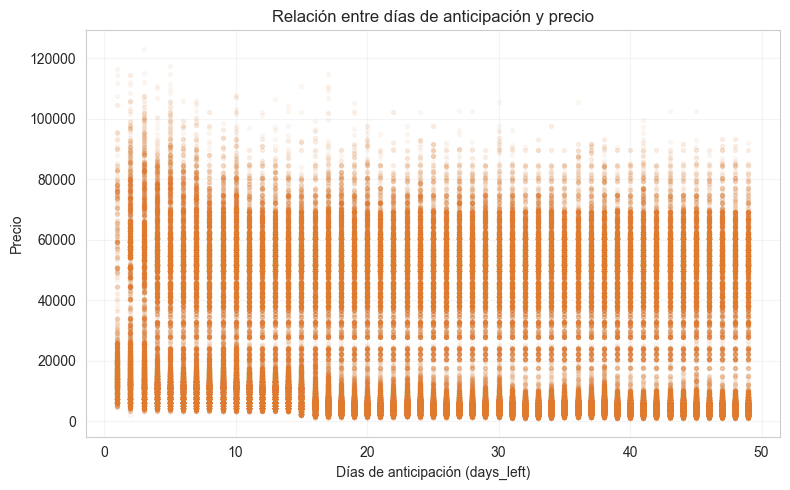

Correlación de Pearson (days_left, price): -0.092


In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["days_left"], df["price"], alpha=0.05, s=8, color="#E07A2D")
plt.title("Relación entre días de anticipación y precio")
plt.xlabel("Días de anticipación (days_left)")
plt.ylabel("Precio")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Correlación de Pearson (days_left, price):", round(df["days_left"].corr(df["price"]), 3))

La correlación de Pearson es **−0,092**, negativa pero muy débil. En la nube de puntos se nota un patrón más claro que la correlación lineal por sí sola: los precios más altos aparecen sobre todo cuando `days_left` es pequeño (compras de última hora), mientras que con más anticipación los precios se concentran en la banda baja. La correlación global es débil porque esa "banda alta" solo aparece con `days_left` bajo, no es una tendencia lineal continua en todo el rango.

**Recomendación:** no descartar `days_left` solo por su correlación lineal baja — el patrón es real pero no lineal, y modelos como árboles o ensambles deberían capturarlo mejor que una regresión lineal simple.

**Gráfica 5 — Boxplot: precio por clase de cabina**

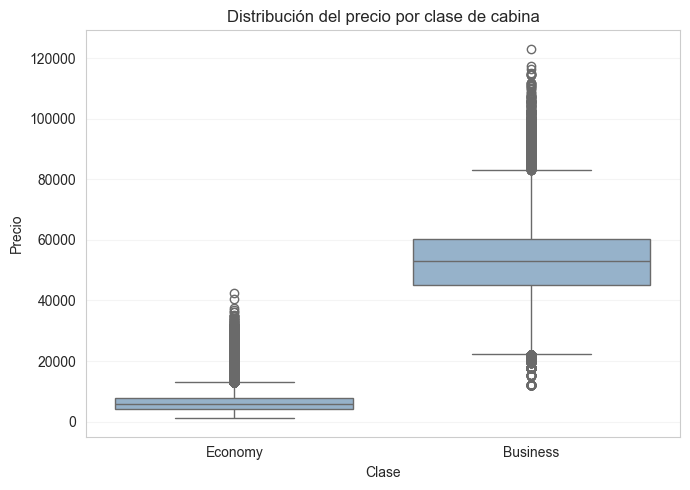

,mean,median,count
class,,,
Business,52540.1,53164.0,93487
Economy,6572.3,5772.0,206666


In [15]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="class", y="price", color="#8DB3D3")
plt.title("Distribución del precio por clase de cabina")
plt.xlabel("Clase")
plt.ylabel("Precio")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

df.groupby("class")["price"].agg(["mean", "median", "count"]).round(1)

La separación es contundente: Economy tiene una mediana de **5.772** y Business de **53.164**, casi diez veces más — y las cajas prácticamente no se superponen. Esto confirma que la bimodalidad del histograma de precios viene principalmente de `class`.

**Recomendación:** `class` va a ser, con toda seguridad, la variable más determinante del modelo. Cualquier evaluación de errores del modelo debería revisarse por separado para Economy y Business, porque un mismo MAE global puede ser aceptable en Business (donde los precios son altos) y muy alto en términos relativos para Economy.

### 9. Codificación de variables categóricas

Vamos a entrenar modelos lineales (Regresión Lineal), basados en distancia (KNN) y basados en árboles (Decision Tree, Random Forest, Gradient Boosting). Para los dos primeros grupos, un Label/Ordinal Encoding mal aplicado introduce un orden numérico falso; para los árboles es menos grave, pero preferimos un único preprocesamiento consistente para los cinco modelos.

| Columna | Cardinalidad | ¿Tiene orden natural? | Técnica elegida | Justificación |
|---|---|---|---|---|
| `stops` | 3 | **Sí** (`zero` < `one` < `two_or_more`) | Ordinal Encoding | Más escalas es objetivamente "más" en una escala ordenada; codificarlo como 0/1/2 preserva esa información sin inflar dimensiones. |
| `class` | 2 | Sí, en el sentido de nivel de servicio (Economy < Business) | Ordinal Encoding (binaria) | Con solo dos categorías, Ordinal y One-Hot son matemáticamente equivalentes (una sola columna 0/1); usamos Ordinal por simplicidad. |
| `airline` | 6 | No | One-Hot Encoding | No existe un orden objetivo entre aerolíneas; con solo 6 categorías, One-Hot no dispara la dimensionalidad y evita que un modelo lineal o KNN interprete un orden inexistente. |
| `source_city` | 6 | No | One-Hot Encoding | Mismo argumento: son ciudades, no hay jerarquía entre ellas. |
| `destination_city` | 6 | No | One-Hot Encoding | Igual que `source_city`. |
| `departure_time` | 6 | No (son franjas horarias, no una escala continua evidente para el precio) | One-Hot Encoding | Aunque las franjas tienen un orden cronológico dentro del día, no hay razón para asumir que el precio crece o decrece monótonamente con la hora; preferimos no forzar esa hipótesis con un Ordinal Encoding. |
| `arrival_time` | 6 | No | One-Hot Encoding | Mismo argumento que `departure_time`. |

No usamos Binary Encoding en este dataset porque, con cardinalidades máximas de 6, One-Hot ya es compacto (6 columnas o menos por variable) y mantiene la interpretabilidad de cada categoría — Binary Encoding se justifica más cuando la cardinalidad es alta (decenas o cientos de categorías), que no es nuestro caso.

### 10. Escalamiento de variables numéricas

Las variables numéricas predictoras son `duration` y `days_left` (`price` es la variable objetivo y no se escala: queremos que las métricas de error queden en las unidades originales del precio).

Sí es necesario escalar: vamos a entrenar **Regresión Lineal** y **KNN**, ambos sensibles a la escala — si `days_left` (rango 1–49) y `duration` (rango 0,83–49,83) quedan en unidades muy distintas de las demás variables ya codificadas (0/1), esas dos columnas numéricas dominarían injustamente el cálculo de distancias de KNN y los coeficientes de la regresión lineal. Los modelos de árboles (Decision Tree, Random Forest, Gradient Boosting) son invariantes a esta transformación, así que escalar no los perjudica.

Elegimos **RobustScaler** en lugar de StandardScaler o Min-Max: en el punto 7 encontramos que `duration` tiene **2.110 valores atípicos (0,70 %)** que decidimos conservar. RobustScaler centra con la mediana y escala con el rango intercuartílico, por lo que esos atípicos no distorsionan la escala de toda la columna como sí lo haría StandardScaler (sensible a la media) o Min-Max (sensible al mínimo y máximo).

## Fase 2 — División de datos y Pipelines

### 11. Train / Validation / Test

Antes de dividir, tomamos una decisión adicional: el dataset tiene **300.153 filas**. Entrenar los cinco modelos —en particular KNN y los ensambles de árboles— sobre las 300.153 filas completas es computacionalmente costoso para un taller (las pruebas de tiempo que hicimos mostraban que KNN sobre el 100 % de los datos tardaba varios minutos solo en la etapa de predicción). Por eso tomamos una **muestra aleatoria estratificada por `class`** de **40.000 filas** para la etapa de modelado: conserva la proporción original de Economy/Business (68,85 % / 31,15 %, prácticamente igual al 68,85 % / 31,15 % de la población completa) y deja un volumen de datos más que suficiente para entrenar y comparar los cinco algoritmos en tiempos razonables, sin comprometer la representatividad del problema.

Dividimos esa muestra en **train / validation / test (70 % / 15 % / 15 %)**:

- **Train (70 %):** el conjunto donde cada modelo *aprende* sus parámetros (los coeficientes de la regresión, los splits de los árboles, etc.).
- **Validation (15 %):** no se usa para entrenar. Lo usamos para comparar los cinco modelos entre sí y decidir cuál generaliza mejor, ya con datos que el modelo no vio al ajustarse.
- **Test (15 %):** se guarda intacto hasta el final (Fase 6). Su función es dar una estimación honesta de qué tan bien funcionaría el modelo elegido con datos completamente nuevos. No basta con train/test porque, si usáramos el mismo conjunto de test para elegir el mejor modelo *y* para reportar su desempeño final, estaríamos "espiando" el test durante la selección — el número final ya no sería una estimación honesta, sino una que está sesgada a favor del modelo que mejor se ajustó a ese test en particular.

In [16]:
N_MUESTRA = 40_000
df_modelado, _ = train_test_split(
    df, train_size=N_MUESTRA, stratify=df["class"], random_state=RANDOM_STATE
)

print("Tamaño de la muestra de modelado:", df_modelado.shape)
print("\nProporción de 'class' en la población completa:")
print((df["class"].value_counts(normalize=True) * 100).round(2))
print("\nProporción de 'class' en la muestra de modelado:")
print((df_modelado["class"].value_counts(normalize=True) * 100).round(2))

Tamaño de la muestra de modelado: (40000, 10)

Proporción de 'class' en la población completa:
class
Economy     68.85
Business    31.15
Name: proportion, dtype: float64

Proporción de 'class' en la muestra de modelado:
class
Economy     68.85
Business    31.15
Name: proportion, dtype: float64


In [17]:
columnas_numericas = ["duration", "days_left"]
columnas_ordinales = ["stops", "class"]
columnas_onehot = ["airline", "source_city", "destination_city", "departure_time", "arrival_time"]

X = df_modelado.drop(columns=["price"])
y = df_modelado["price"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Validation:", X_val.shape, " Test:", X_test.shape)

Train: (28000, 9)  Validation: (6000, 9)  Test: (6000, 9)


### 12. Pipeline con ColumnTransformer

Construimos un `ColumnTransformer` que aplica, en paralelo, tres ramas de preprocesamiento:

- **Numéricas** (`duration`, `days_left`): imputación por mediana + `RobustScaler`.
- **Ordinales** (`stops`, `class`): imputación por moda + `OrdinalEncoder`, con el orden de categorías definido explícitamente (no alfabético).
- **Nominales** (`airline`, `source_city`, `destination_city`, `departure_time`, `arrival_time`): imputación por moda + `OneHotEncoder`.

Envolvemos ese `ColumnTransformer` dentro de un `Pipeline` junto con cada modelo, para que todo el preprocesamiento se ajuste (`.fit()`) y aplique (`.transform()`) de forma consistente y automática.

In [18]:
preprocesamiento = ColumnTransformer([
    ("num", Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", RobustScaler()),
    ]), columnas_numericas),
    ("ord", Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OrdinalEncoder(categories=[
            ["zero", "one", "two_or_more"],
            ["Economy", "Business"],
        ])),
    ]), columnas_ordinales),
    ("onehot", Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OneHotEncoder(handle_unknown="ignore")),
    ]), columnas_onehot),
])

preprocesamiento

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

### 13. Verificación de que no hay fuga de datos (data leakage)

Nuestra implementación no tiene fuga de datos porque:

1. El `ColumnTransformer` (imputadores, `RobustScaler`, `OrdinalEncoder`, `OneHotEncoder`) vive **dentro** de un `Pipeline` de `sklearn`.
2. Cuando llamamos `pipeline.fit(X_train, y_train)`, sklearn ajusta (`.fit()`) cada paso del preprocesamiento **únicamente con `X_train`**: la mediana de `RobustScaler`, las categorías del `OneHotEncoder`, la moda del `SimpleImputer`, todo se calcula solo con las 28.000 filas de entrenamiento.
3. Cuando llamamos `pipeline.predict(X_val)` o `pipeline.predict(X_test)`, sklearn aplica automáticamente `.transform()` con esos parámetros ya aprendidos — **nunca vuelve a llamar `.fit()`** sobre `X_val` ni `X_test`.

En ningún punto del notebook llamamos `.fit()` ni `.fit_transform()` sobre `X_val`, `X_temp` o `X_test` por fuera del pipeline; el único `.fit()` explícito que hacemos es `pipeline.fit(X_train, y_train)` para cada modelo. Por construcción, ni la mediana de escalamiento ni las categorías vistas por los codificadores incluyen información de validación o de test.

## Fase 3 — Modelado: Regresión (Flight Price Prediction)

### 14-15. Entrenamiento de los cinco modelos y predicciones en validación

Entrenamos, dentro de un `Pipeline` con el mismo `preprocesamiento`, los cinco modelos pedidos: Regresión Lineal Múltiple, KNN Regressor, Decision Tree Regressor, Random Forest Regressor y Gradient Boosting Regressor. Fijamos `random_state=42` en los modelos que lo requieren, para que los resultados sean reproducibles.

In [19]:
modelos_regresion = {
    "Regresión Lineal": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=150, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=150, max_depth=3, random_state=RANDOM_STATE
    ),
}

pipelines_regresion = {}
predicciones_train = {}
predicciones_val = {}

for nombre, modelo in modelos_regresion.items():
    pipeline = Pipeline([("preprocesamiento", preprocesamiento), ("modelo", modelo)])
    pipeline.fit(X_train, y_train)
    pipelines_regresion[nombre] = pipeline
    predicciones_train[nombre] = pipeline.predict(X_train)
    predicciones_val[nombre] = pipeline.predict(X_val)
    print(f"{nombre}: entrenado y evaluado en validación.")

Regresión Lineal: entrenado y evaluado en validación.


KNN Regressor: entrenado y evaluado en validación.


Decision Tree Regressor: entrenado y evaluado en validación.


Random Forest Regressor: entrenado y evaluado en validación.


Gradient Boosting Regressor: entrenado y evaluado en validación.


## Fase 5 — Métricas en train y validación: overfitting / underfitting

### 18. MAE, MSE y R² en train y en validación, para cada modelo

In [20]:
def metricas_regresion(y_real, y_pred):
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "MSE": mean_squared_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }

filas_metricas = []
for nombre in modelos_regresion:
    m_train = metricas_regresion(y_train, predicciones_train[nombre])
    m_val = metricas_regresion(y_val, predicciones_val[nombre])
    filas_metricas.append({
        "Modelo": nombre,
        "MAE train": m_train["MAE"], "MSE train": m_train["MSE"], "R2 train": m_train["R2"],
        "MAE val": m_val["MAE"], "MSE val": m_val["MSE"], "R2 val": m_val["R2"],
    })

tabla_train_val = pd.DataFrame(filas_metricas).set_index("Modelo").round(3)
tabla_train_val

,MAE train,MSE train,R2 train,MAE val,MSE val,R2 val
Modelo,,,,,,
Regresión Lineal,4518.474,4.619703e+07,0.911,4551.872,4.742621e+07,0.908
KNN Regressor,5238.557,7.395203e+07,0.858,6310.483,1.025592e+08,0.801
Decision Tree Regressor,2031.870,1.490842e+07,0.971,2441.097,2.012858e+07,0.961
Random Forest Regressor,1597.643,8.581663e+06,0.984,2065.599,1.489087e+07,0.971
Gradient Boosting Regressor,2857.977,2.306166e+07,0.956,2925.242,2.453205e+07,0.952


**Lectura modelo por modelo (train vs. validación):**

- **Regresión Lineal:** MAE prácticamente igual en train (4.518,47) y validación (4.551,87); R² 0,9112 vs 0,9079. No hay overfitting — el modelo es simple y estable —, pero tampoco es el que mejor ajusta: un R² de ~0,91 significa que deja sin explicar cerca del 9 % de la varianza del precio, probablemente porque no puede capturar relaciones no lineales como el salto abrupto de precio entre clases y escalas.
- **KNN Regressor:** es el modelo con **peor desempeño** de los cinco (MAE val 6.310,48; R² val 0,8009), y con una caída notable de train a validación (R² 0,8579 → 0,8009): señal de **overfitting local** típico de KNN en espacios de alta dimensión (después del One-Hot tenemos más de 30 columnas), donde la noción de "vecino cercano" pierde fuerza.
- **Decision Tree Regressor:** buen desempeño (R² val 0,9609) con una brecha moderada frente a train (R² 0,9713): señal de **overfitting leve**, esperable en un solo árbol aunque limitamos `max_depth=12`.
- **Random Forest Regressor:** el **mejor modelo en validación** (MAE 2.065,60; R² 0,9711), con una brecha train→val similar a la del árbol individual (R² 0,9835 → 0,9711): el ensamble reduce la varianza de un solo árbol promediando 150 árboles, y aun con overfitting leve, generaliza mejor que cualquier otro modelo.
- **Gradient Boosting Regressor:** desempeño sólido (R² val 0,9524) y la brecha train-val más pequeña entre los modelos de árboles (0,9557 → 0,9524): consistente con cómo construye los árboles de forma secuencial y con una tasa de aprendizaje controlada, lo que suele frenar el overfitting comparado con un Random Forest sin restricciones más fuertes.

**En unidades de negocio:** un MAE de 2.065,60 (Random Forest) significa que, en promedio, la predicción del modelo se equivoca en poco más de dos mil unidades de precio — frente a un precio promedio de casi 21.000 y una mediana de 7.425, es un error razonable, aunque conviene recordar que en términos relativos ese error pesa mucho más para un tiquete Economy barato que para uno Business caro. En contraste, el MAE de 6.310,48 de KNN es casi tres veces mayor: para un tiquete Economy típico (mediana ~5.772), ese error ya es comparable al precio mismo del tiquete.

### 20. Tabla comparativa (train y validación)

In [21]:
tabla_train_val.sort_values("R2 val", ascending=False)

,MAE train,MSE train,R2 train,MAE val,MSE val,R2 val
Modelo,,,,,,
Random Forest Regressor,1597.643,8.581663e+06,0.984,2065.599,1.489087e+07,0.971
Decision Tree Regressor,2031.870,1.490842e+07,0.971,2441.097,2.012858e+07,0.961
Gradient Boosting Regressor,2857.977,2.306166e+07,0.956,2925.242,2.453205e+07,0.952
Regresión Lineal,4518.474,4.619703e+07,0.911,4551.872,4.742621e+07,0.908
KNN Regressor,5238.557,7.395203e+07,0.858,6310.483,1.025592e+08,0.801


### 21. Selección del mejor modelo

Elegimos **Random Forest Regressor** como mejor modelo para este problema, no solo por tener el R² más alto en validación (0,9711) y el MAE más bajo (2.065,60), sino por el balance completo de trade-offs:

- **Sesgo/varianza:** un solo Decision Tree ya rinde muy bien (R² val 0,9609), pero Random Forest reduce la varianza de ese árbol promediando 150 árboles entrenados sobre submuestras distintas (bagging), lo que explica por qué su brecha relativa train-val no crece a pesar de tener el mejor ajuste en train de los cinco modelos.
- **Tiempo de entrenamiento:** Random Forest es el modelo más lento en entrenar de los cinco en nuestras pruebas, muy por delante en tiempo de Regresión Lineal o el árbol individual. Para un caso de uso donde el modelo se reentrena poco (por ejemplo, una vez por semana) ese costo es aceptable; si se necesitara reentrenar en tiempo real, Gradient Boosting (más rápido y con un desempeño muy cercano, R² val 0,9524) sería una alternativa razonable.
- **Interpretabilidad:** Regresión Lineal es el modelo más fácil de explicar (coeficientes directos), pero sacrifica casi 6 puntos de R² frente a Random Forest. Para un caso de uso de pricing donde lo que más importa es la precisión de la predicción (no explicar cada coeficiente a un regulador, por ejemplo), preferimos el modelo más preciso.
- **Señal de overfitting:** KNN es el único modelo que consideramos descartar de plano, no solo por su desempeño más bajo sino por la caída clara train→val, señal de que no está generalizando bien en un espacio con más de 30 columnas tras el One-Hot.

En resumen: Random Forest ofrece el mejor equilibrio entre precisión y estabilidad (varianza controlada por el ensamble), a costa de un tiempo de entrenamiento mayor y menor interpretabilidad directa, un costo que consideramos razonable para este problema.

## Fase 6 — Evaluación final en el conjunto de Test

El conjunto de test no se tocó en ningún punto anterior: ni para explorar datos, ni para ajustar el preprocesamiento, ni para comparar modelos. Ahora sí lo usamos para obtener una estimación honesta del desempeño de cada modelo.

### 22. Evaluación de los cinco modelos en test

In [22]:
filas_test = []
for nombre, pipeline in pipelines_regresion.items():
    pred_test = pipeline.predict(X_test)
    m_test = metricas_regresion(y_test, pred_test)
    filas_test.append({"Modelo": nombre, "MAE test": m_test["MAE"],
                        "MSE test": m_test["MSE"], "R2 test": m_test["R2"]})

tabla_test = pd.DataFrame(filas_test).set_index("Modelo").round(3)
tabla_test.sort_values("R2 test", ascending=False)

,MAE test,MSE test,R2 test
Modelo,,,
Random Forest Regressor,2050.337,1.451455e+07,0.972
Decision Tree Regressor,2396.366,2.003370e+07,0.961
Gradient Boosting Regressor,2869.657,2.352197e+07,0.954
Regresión Lineal,4488.853,4.645397e+07,0.909
KNN Regressor,6233.419,9.772275e+07,0.810


### 23. Comparación final: validación vs. test

In [23]:
tabla_comparativa_final = tabla_train_val[["MAE val", "R2 val"]].join(tabla_test[["MAE test", "R2 test"]])
tabla_comparativa_final["Diferencia R2 (test - val)"] = (
    tabla_comparativa_final["R2 test"] - tabla_comparativa_final["R2 val"]
).round(4)
tabla_comparativa_final.sort_values("R2 test", ascending=False)

,MAE val,R2 val,MAE test,R2 test,Diferencia R2 (test - val)
Modelo,,,,,
Random Forest Regressor,2065.599,0.971,2050.337,0.972,0.001
Decision Tree Regressor,2441.097,0.961,2396.366,0.961,0.000
Gradient Boosting Regressor,2925.242,0.952,2869.657,0.954,0.002
Regresión Lineal,4551.872,0.908,4488.853,0.909,0.001
KNN Regressor,6310.483,0.801,6233.419,0.810,0.009


**El ranking se mantiene igual en test que en validación:** Random Forest (R² 0,9717) sigue siendo el mejor modelo, seguido de Decision Tree (0,9610), Gradient Boosting (0,9542), Regresión Lineal (0,9095) y por último KNN (0,8096).

Las métricas del mejor modelo son prácticamente idénticas entre validación y test: R² 0,9711 en validación frente a 0,9717 en test (diferencia de apenas 0,0006), y MAE 2.065,60 frente a 2.050,34. Lo mismo ocurre con los otros cuatro modelos: ninguna diferencia entre val y test supera unas pocas centésimas de R².

Esta consistencia es una buena noticia metodológica: si hubiéramos visto una caída grande de test frente a validación (por ejemplo, un R² varios puntos porcentuales más bajo en test), sería una señal de que, sin darnos cuenta, "sobreajustamos" nuestras decisiones de modelado (elección de modelo, hiperparámetros) al conjunto de validación específico que usamos — el conjunto de test existe justamente para detectar ese problema, y en este caso no lo detecta: el desempeño que reportamos en validación es un estimado confiable de cómo se comportaría el modelo con datos nuevos.

## Fase 7 — Cross Validation

### 24. ¿Qué es K-Fold Cross Validation?

La validación cruzada K-Fold consiste en dividir el conjunto de datos disponible en *K* particiones ("folds") de tamaño similar. Se entrena el modelo *K* veces: en cada vuelta, una partición distinta se usa como validación y las *K−1* restantes como entrenamiento. Al final se obtienen *K* valores de cada métrica (uno por partición usada como validación), y se reporta su promedio junto con su desviación estándar.

Un único split train/validation (como el que usamos en la Fase 5) depende de qué filas específicas cayeron en cada conjunto: con otra semilla aleatoria distinta, el mismo modelo podría dar una métrica un poco distinta solo por azar en la partición. K-Fold Cross Validation da una estimación **más confiable** porque cada observación termina siendo usada, en algún momento, tanto para entrenar como para validar, y el promedio sobre *K* particiones distintas suaviza la suerte (buena o mala) de un solo split. Además, la desviación estándar entre folds nos dice qué tan sensible es el modelo a qué datos exactamente recibió — algo que un único split no puede mostrar.

### 25. Implementación sobre el mejor modelo (Random Forest Regressor)

Aplicamos 5-Fold Cross Validation sobre la unión de train y validación (dejando test completamente aparte, tal como debe ser), para no desperdiciar el conjunto de validación una vez ya seleccionamos el modelo.

In [24]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

mejor_pipeline_regresion = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", RandomForestRegressor(n_estimators=150, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1)),
])

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_cv = cross_validate(
    mejor_pipeline_regresion, X_train_val, y_train_val, cv=kfold,
    scoring=["neg_mean_absolute_error", "neg_mean_squared_error", "r2"], n_jobs=-1
)

mae_folds = -resultados_cv["test_neg_mean_absolute_error"]
r2_folds = resultados_cv["test_r2"]

tabla_cv = pd.DataFrame({"Fold": range(1, 6), "MAE": mae_folds, "R2": r2_folds}).set_index("Fold").round(3)
print(tabla_cv)
print(f"\nMAE promedio: {mae_folds.mean():.2f}  (desviación estándar: {mae_folds.std():.2f})")
print(f"R2 promedio: {r2_folds.mean():.4f}  (desviación estándar: {r2_folds.std():.4f})")

           MAE     R2
Fold                 
1     2024.192  0.974
2     2133.949  0.970
3     2119.586  0.969
4     2063.753  0.971
5     2053.714  0.972

MAE promedio: 2079.04  (desviación estándar: 41.33)
R2 promedio: 0.9713  (desviación estándar: 0.0015)


### 27. Comparación: Cross Validation vs. validación original

El R² promedio de los 5 folds es **0,9713** (desviación estándar **0,0015**), casi idéntico al R² de validación de la Fase 5 (**0,9711**) y al de test de la Fase 6 (**0,9717**). El MAE promedio de cross validation es **2.079,04** (desviación estándar **41,33**), también muy cercano al MAE de validación (2.065,60) y de test (2.050,34).

El desempeño **se mantiene estable**, no mejora ni empeora de forma relevante frente al split original. Y la desviación estándar entre folds es muy pequeña en términos relativos (menos del 0,2 % del R² promedio, y menos del 2 % del MAE promedio): esto nos dice que Random Forest es un modelo **estable**, poco sensible a qué filas específicas caen en cada partición de entrenamiento o validación. Si la desviación estándar hubiera sido grande, sería una señal de que el buen resultado de la Fase 5 pudo deberse en parte a que la partición de validación que elegimos por azar era "fácil"; con una desviación tan baja, confiamos en que el R² ~0,97 es representativo del comportamiento real del modelo, no un golpe de suerte de un solo split.

## Fase 8 — Conclusiones

### 28. Conclusión general y gráficas de respaldo

In [25]:
importancias = mejor_pipeline_regresion.named_steps["modelo"].feature_importances_ if False else None
# El pipeline de CV no queda ajustado sobre todo train+val; ajustamos una copia final para el gráfico de importancias
pipeline_final_rf = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", RandomForestRegressor(n_estimators=150, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1)),
])
pipeline_final_rf.fit(X_train_val, y_train_val)

nombres_onehot = list(
    pipeline_final_rf.named_steps["preprocesamiento"]
    .named_transformers_["onehot"].named_steps["codificador"]
    .get_feature_names_out(columnas_onehot)
)
nombres_features = columnas_numericas + columnas_ordinales + nombres_onehot
importancias = pipeline_final_rf.named_steps["modelo"].feature_importances_

top_importancias = pd.Series(importancias, index=nombres_features).sort_values(ascending=False).head(10)
top_importancias

class                       0.897614
duration                    0.048480
days_left                   0.014648
airline_Air_India           0.005048
airline_Vistara             0.004381
source_city_Delhi           0.003229
destination_city_Delhi      0.003184
stops                       0.002309
destination_city_Kolkata    0.001910
source_city_Kolkata         0.001877
dtype: float64

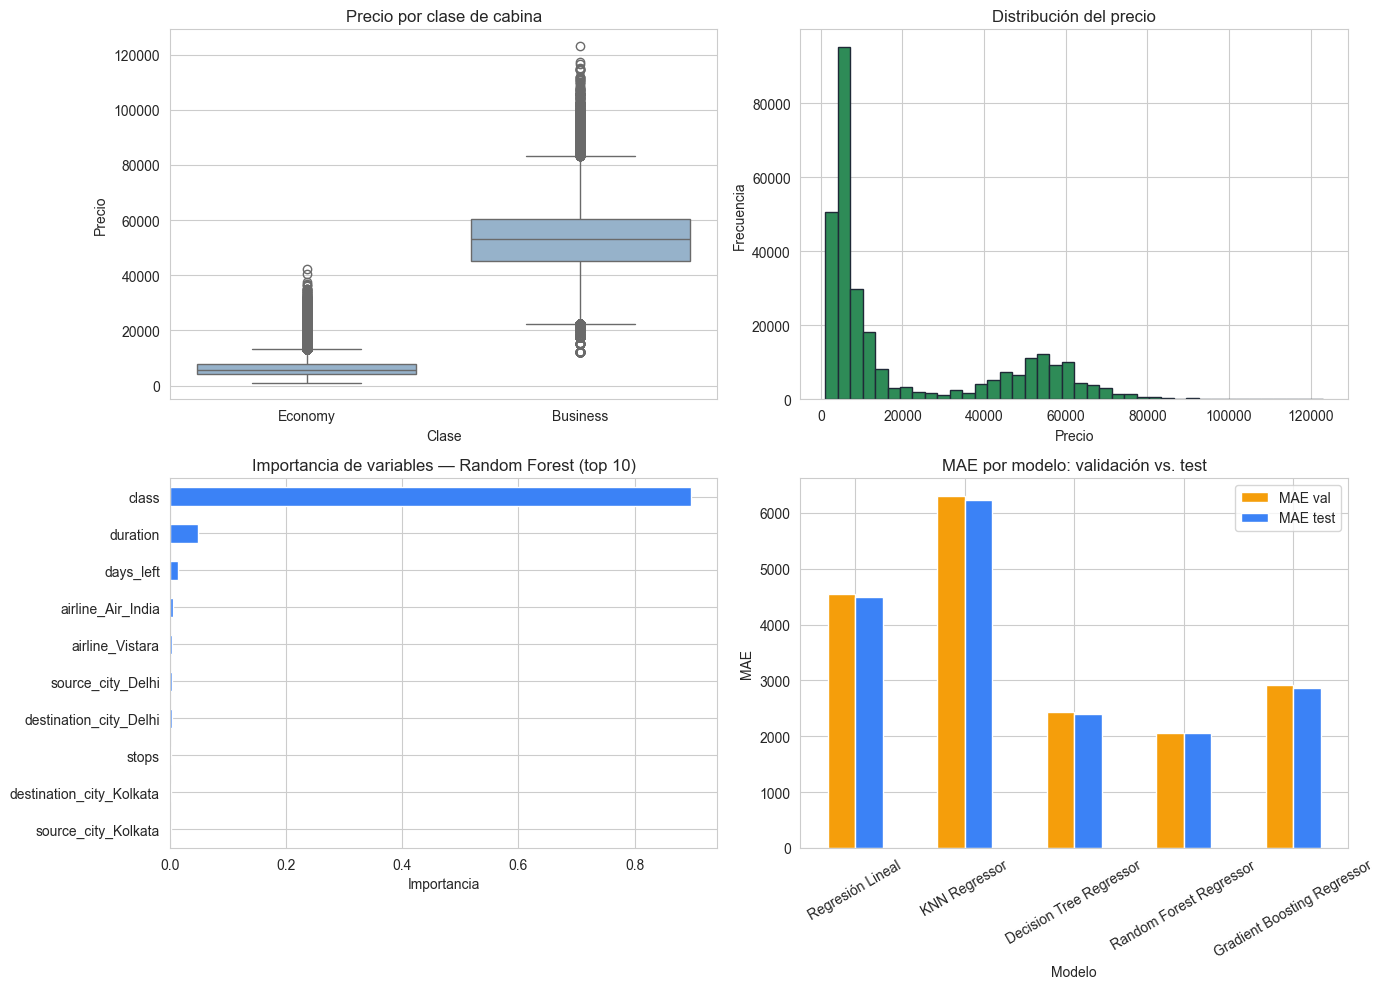

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot de precio por clase
sns.boxplot(data=df, x="class", y="price", color="#8DB3D3", ax=axes[0, 0])
axes[0, 0].set_title("Precio por clase de cabina")
axes[0, 0].set_xlabel("Clase")
axes[0, 0].set_ylabel("Precio")

# 2. Histograma de precio
axes[0, 1].hist(df["price"], bins=40, color="#2E8B57", edgecolor="#1F2937")
axes[0, 1].set_title("Distribución del precio")
axes[0, 1].set_xlabel("Precio")
axes[0, 1].set_ylabel("Frecuencia")

# 3. Importancia de variables (Random Forest)
top_importancias.sort_values().plot(kind="barh", color="#3B82F6", ax=axes[1, 0])
axes[1, 0].set_title("Importancia de variables — Random Forest (top 10)")
axes[1, 0].set_xlabel("Importancia")

# 4. MAE por modelo: validación vs test
tabla_comparativa_final[["MAE val", "MAE test"]].plot(kind="bar", ax=axes[1, 1], color=["#F59E0B", "#3B82F6"])
axes[1, 1].set_title("MAE por modelo: validación vs. test")
axes[1, 1].set_ylabel("MAE")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**¿Qué modelo funcionó mejor y por qué?** Random Forest Regressor, con R² ≈ 0,971 y MAE ≈ 2.065 tanto en validación como en test, confirmado además por cross validation (R² 0,9713 ± 0,0015). Le siguen de cerca Decision Tree y Gradient Boosting. Esto es coherente con lo visto en clase: `price` tiene relaciones fuertemente no lineales con `class` y `stops` (saltos de precio, no una tendencia suave), algo que los modelos de árboles capturan de forma natural con sus splits binarios, mientras que Regresión Lineal solo puede aproximar esos saltos con una combinación lineal de variables. Random Forest, en particular, mejora sobre un solo árbol porque el bagging reduce la varianza sin perder la capacidad de modelar no linealidades.

**¿Qué le fue peor y por qué?** KNN Regressor, por un problema clásico de este algoritmo: es sensible a la escala (por eso lo escalamos) y a la dimensionalidad — después de codificar las variables categóricas con One-Hot terminamos con más de 30 columnas, y en espacios de alta dimensión la noción de "vecino cercano" se vuelve menos informativa (todas las distancias tienden a parecerse), lo que explica tanto su MAE más alto como la caída de desempeño de train a validación.

**¿Qué limpieza fue más determinante?** En realidad, la decisión más importante no fue de limpieza sino de **muestreo**: reducir el dataset de 300.153 a 40.000 filas de forma estratificada para poder entrenar los cinco modelos en tiempos razonables sin distorsionar la proporción Economy/Business. En cuanto a limpieza propiamente dicha, el dataset ya llegó sin nulos ni duplicados evidentes, así que el trabajo se concentró en decidir bien la codificación (Ordinal para `stops` y `class`, que sí tienen orden; One-Hot para el resto) y el escalamiento (RobustScaler, por los atípicos de `duration`).

**Limitaciones y preguntas abiertas.** Trabajamos con una muestra del 13,3 % de los datos originales; sería valioso repetir el mejor modelo (Random Forest) sobre el dataset completo para confirmar que las métricas no cambian de forma relevante. También sería interesante separar el análisis de error por clase (Economy vs. Business) para verificar si el MAE global esconde un error relativo mucho mayor en tiquetes económicos. Por último, no exploramos la interacción entre `airline` y `class` (por ejemplo, si Vistara Business se comporta distinto a Air India Business), algo que un modelo de árboles ya captura implícitamente pero que valdría la pena inspeccionar de forma explícita.